# 解释collection

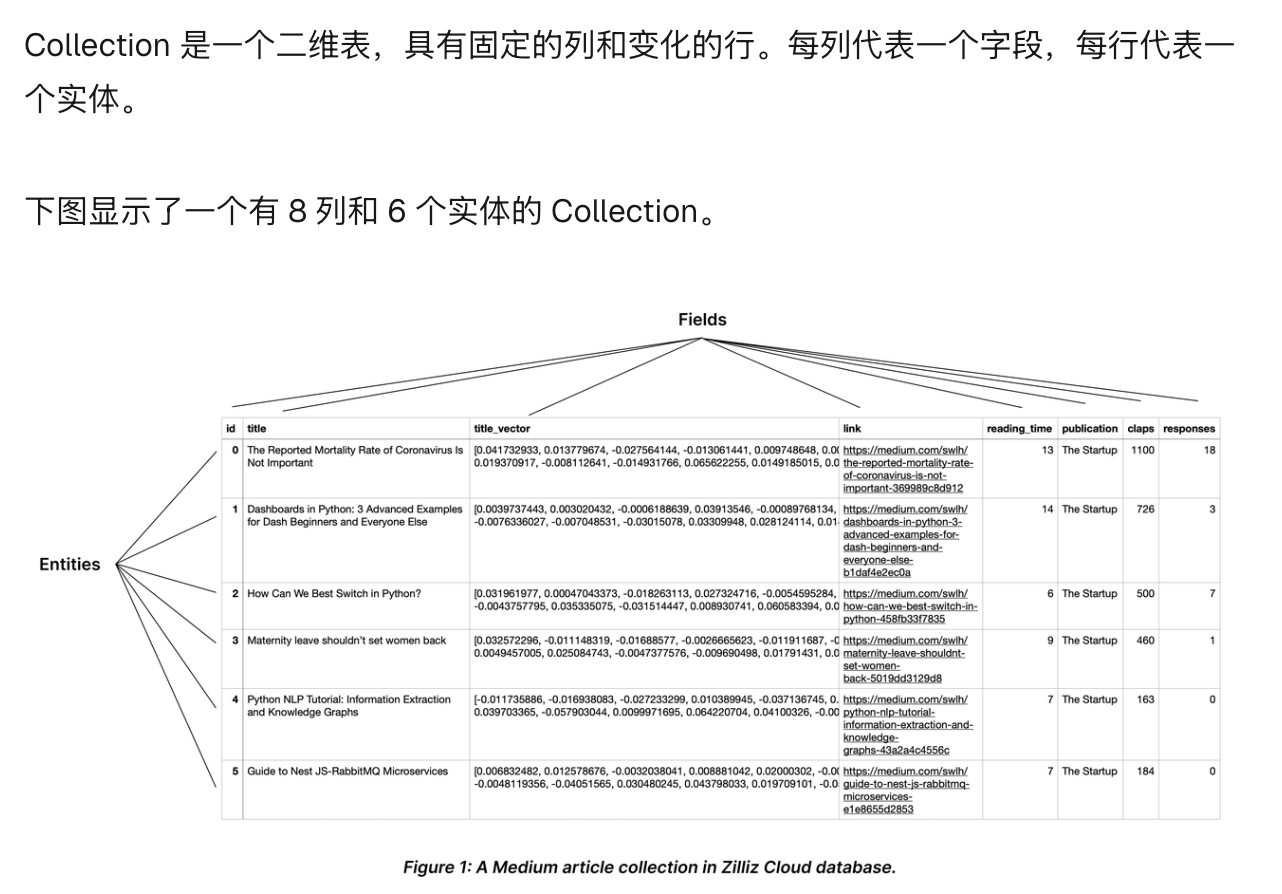  
https://milvus.io/docs/zh/manage-collections.md


# 创建collection

In [2]:
from pymilvus import MilvusClient,DataType


In [26]:
client = MilvusClient(
    uri="http://localhost:19530",
    token="root:Milvus"
)

In [6]:
schema = client.create_schema(
    auto_id=False,
    enable_dynamic_field=True,
)

schema.add_field(field_name="id", datatype=DataType.INT64, is_primary=True)
schema.add_field(field_name="vector", datatype=DataType.FLOAT_VECTOR, dim=128)
schema.add_field(field_name="age", datatype=DataType.INT64)

{'auto_id': False, 'description': '', 'fields': [{'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'is_primary': True, 'auto_id': False}, {'name': 'vector', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 128}}, {'name': 'age', 'description': '', 'type': <DataType.INT64: 5>}], 'enable_dynamic_field': True, 'enable_namespace': False}

In [7]:
index_params = client.prepare_index_params()
index_params.add_index(
    field_name="id",
    index_type="AUTOINDEX"
)

index_params.add_index(
    field_name="vector",
    index_type="IVF_FLAT",
    metric_type="L2"
)

In [10]:
client.create_collection(
    collection_name="demo_collection",
    schema=schema,
    index_params=index_params
)

res = client.get_load_state(collection_name="demo_collection")
print(res)

{'state': <LoadState: Loaded>}


创建不带任何索引参数的 Collections，然后再添加索引参数。在这种情况下，Milvus 不会在创建时加载 Collection。.

In [11]:
client.create_collection(
    collection_name="customized_setup_2",
    schema=schema,
)

res = client.get_load_state(
    collection_name="customized_setup_2"
)

print(res)



{'state': <LoadState: NotLoad>}


## 设置集合属性

In [16]:
# shards  是collection的水平切分数量

# 一般指导原则，在设置分片数量时应考虑以下几点：
# 数据大小：通常的做法是每 2 亿个实体设置一个分区。也可以根据总数据量进行估算，例如，计划插入的数据量每 100 GB 就增加一个分区。
# 流节点利用率：如果你的 Milvus 实例有多个流节点，建议使用多个分片。这样可以确保数据插入工作量分布在所有可用的流节点上，防止一些节点闲置，而其他节点超负荷工作。
client.drop_collection(collection_name="customized_setup_3")
client.create_collection(
    collection_name="customized_setup_3",
    schema=schema,
    shards_num=2,
    enable_mmmp=True, #允许 Milvus 将原始字段数据映射到内存中，而不是完全加载它们。这样可以减少内存占用，提高 Collections 的容量
    properties={
        "collection.ttl.seconds": 3600,  # 设置 TTL（Time To Live）为 3600 秒，即 1 小时
    },
    consistency_level="Bounded"
)


# 查看collection

In [27]:
client.list_collections()

['customized_setup_4', 'demo_collection', 'customized_setup_2']

In [19]:
client.describe_collection(collection_name="customized_setup_3")

{'collection_name': 'customized_setup_3',
 'auto_id': False,
 'num_shards': 2,
 'description': '',
 'fields': [{'field_id': 100,
   'name': 'id',
   'description': '',
   'type': <DataType.INT64: 5>,
   'params': {},
   'is_primary': True},
  {'field_id': 101,
   'name': 'vector',
   'description': '',
   'type': <DataType.FLOAT_VECTOR: 101>,
   'params': {'dim': 128}},
  {'field_id': 102,
   'name': 'age',
   'description': '',
   'type': <DataType.INT64: 5>,
   'params': {}}],
 'functions': [],
 'aliases': [],
 'collection_id': 464321742241327654,
 'consistency_level': 2,
 'properties': {'collection.ttl.seconds': '3600', 'timezone': 'UTC'},
 'num_partitions': 1,
 'enable_dynamic_field': True,
 'enable_namespace': False,
 'created_timestamp': 464393013435039762,
 'update_timestamp': 464393013435039762}

# 修改collection

In [20]:
client.rename_collection(
    old_name="customized_setup_3",
    new_name="customized_setup_4"
)

In [22]:
client.drop_collection_properties(
    collection_name="customized_setup_4",
    property_keys=[
        "collection.ttl.seconds"
    ]
)

# 装载和释放

In [32]:
# client.load_collection(collection_name="customized_setup_2")
client.load_collection(collection_name="demo_collection")

In [37]:
client.list_collections()

['customized_setup_2', 'customized_setup_4', 'demo_collection']

# 设置collection

# 一致性级别

# 管理分区

# 管理别名

# 删除collection